Proyecto Mes 2 - Regresión con Aprendizaje Automático — Beijing PM2.5
Dataset: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv
URL Render: https://deploy-pm2-5-predictor.onrender.com/

1. Compresión del Negocio
El objetivo es predecir la concentración de PM2.5 (µg/m³) en Beijing a partir de variables meteorológicas horarias (2010-2014). PM2.5 representa partículas finas en suspensión con diámetro < 2.5 µm, altamente peligrosas para la salud pulmonar. El modelo puede integrarse en sistemas de alerta temprana para anticipar episodios de contaminación y activar medidas preventivas.

2. Compresion de los Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_validate, train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer
import joblib, os, time, warnings
warnings.filterwarnings('ignore')

SEED = 42
print('Librerías importadas correctamente')

Librerías importadas correctamente


In [2]:
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
df = pd.read_csv(URL)

print(f'Dataset cargado correctamente')
print(f'Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Dataset cargado correctamente
Registros: 43,824 | Columnas: 13


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [4]:
# Resumen: tipos, nulos y valores únicos
resumen = pd.DataFrame({
    'Tipo':    df.dtypes,
    'Nulos':   df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos':  df.nunique()
})
display(resumen)

print(f'Registros duplicados: {df.duplicated().sum()}')

,Tipo,Nulos,% Nulos,Únicos
No,int64,0,0.00,43824
year,int64,0,0.00,5
month,int64,0,0.00,12
day,int64,0,0.00,31
hour,int64,0,0.00,24
pm2.5,float64,2067,4.72,581
DEWP,int64,0,0.00,69
TEMP,float64,0,0.00,64
PRES,float64,0,0.00,60
cbwd,str,0,0.00,4


Registros duplicados: 0


EDA — Análisis Exploratorio de Datos

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
No,43824.0,21912.50,12651.04,1.00,10956.75,21912.50,32868.25,43824.0
year,43824.0,2012.00,1.41,2010.00,2011.00,2012.00,2013.00,2014.0
month,43824.0,6.52,3.45,1.00,4.00,7.00,10.00,12.0
day,43824.0,15.73,8.80,1.00,8.00,16.00,23.00,31.0
hour,43824.0,11.50,6.92,0.00,5.75,11.50,17.25,23.0
pm2.5,41757.0,98.61,92.05,0.00,29.00,72.00,137.00,994.0
DEWP,43824.0,1.82,14.43,-40.00,-10.00,2.00,15.00,28.0
TEMP,43824.0,12.45,12.20,-19.00,2.00,14.00,23.00,42.0
PRES,43824.0,1016.45,10.27,991.00,1008.00,1016.00,1025.00,1046.0
Iws,43824.0,23.89,50.01,0.45,1.79,5.37,21.91,585.6


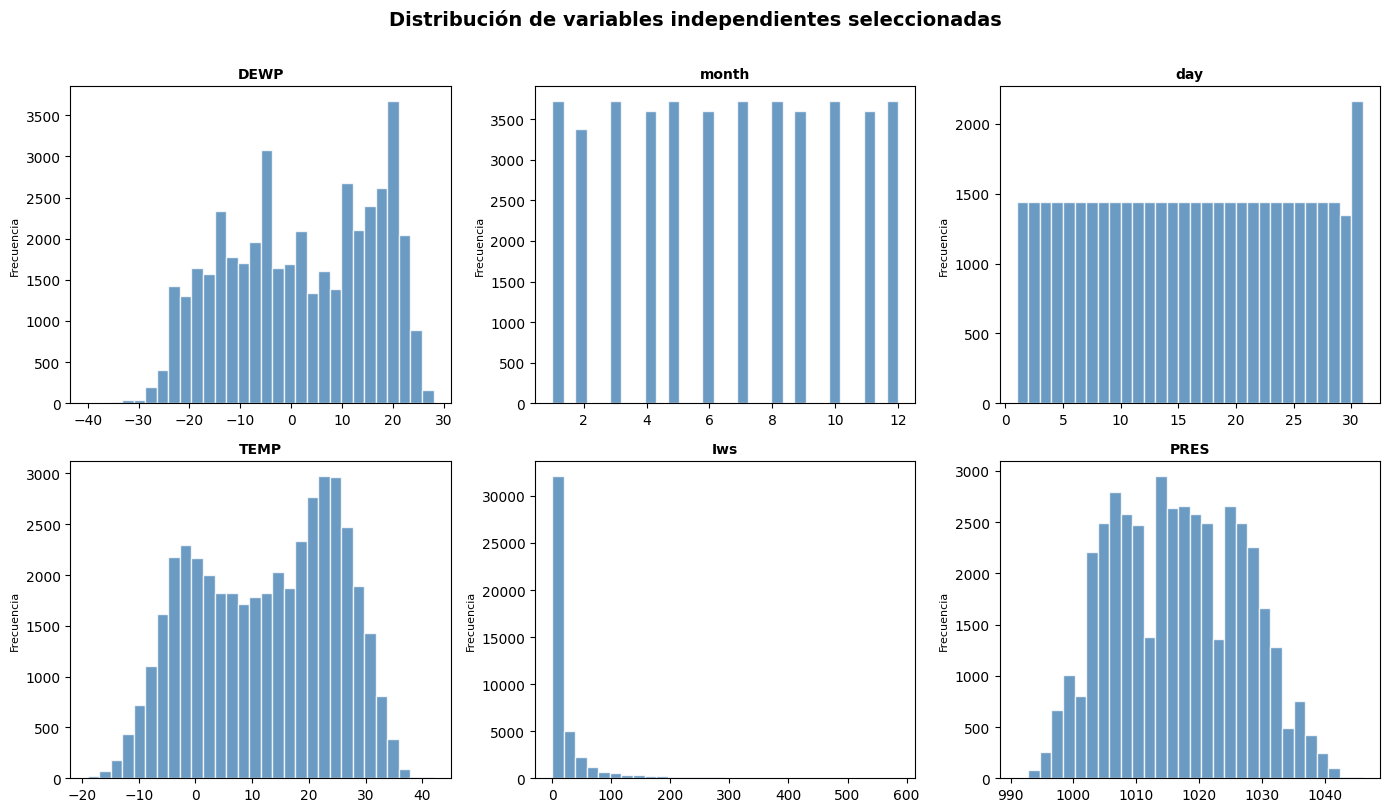

In [34]:
features = ['DEWP', 'month', 'day', 'TEMP', 'Iws', 'PRES']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia', fontsize=8)

plt.suptitle('Distribución de variables independientes seleccionadas', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

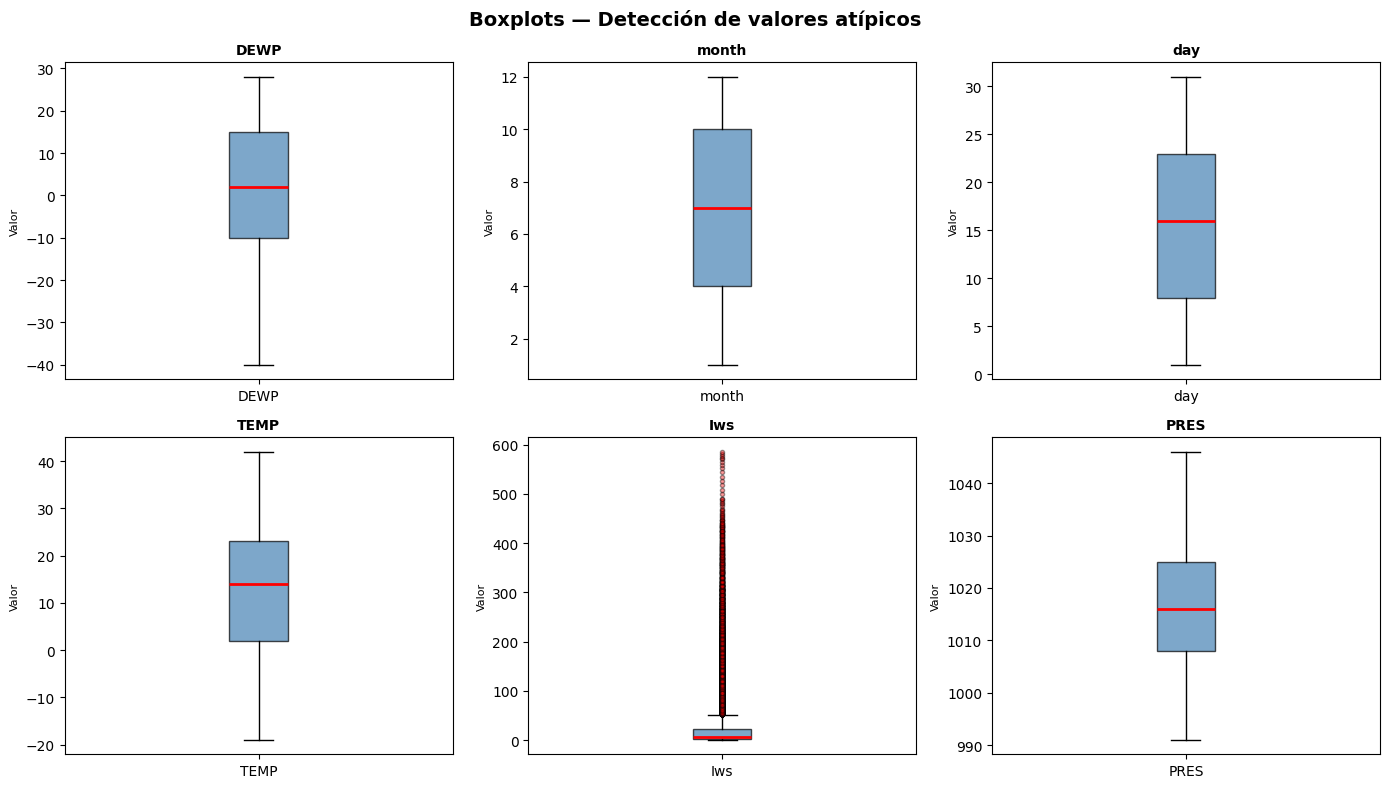

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(['DEWP', 'month', 'day', 'TEMP', 'Iws', 'PRES']):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor', fontsize=8)
    axes[i].set_xticklabels([col])

plt.suptitle('Boxplots — Detección de valores atípicos', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

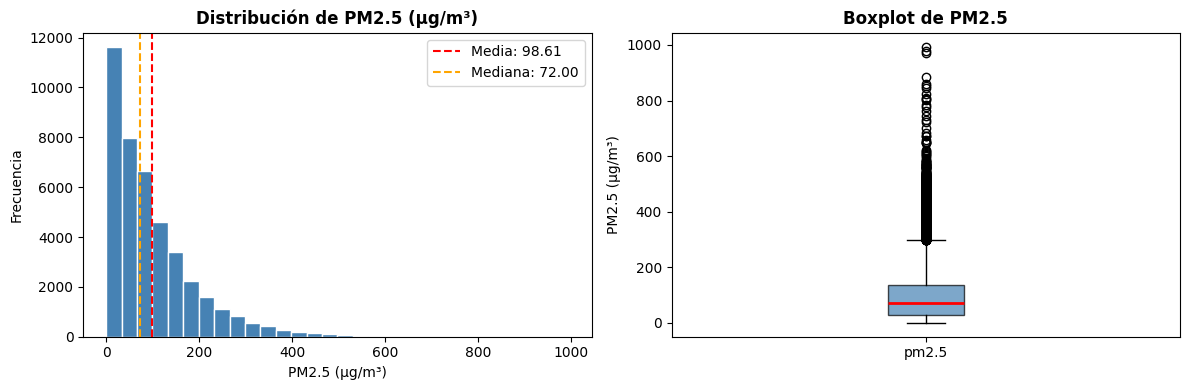

Asimetría (skewness): 1.8023
Curtosis: 4.7689
Valores únicos: 581


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pm2.5'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['pm2.5'].mean(), color='red', linestyle='--', label=f'Media: {df["pm2.5"].mean():.2f}')
axes[0].axvline(df['pm2.5'].median(), color='orange', linestyle='--', label=f'Mediana: {df["pm2.5"].median():.2f}')
axes[0].legend()

axes[1].boxplot(df['pm2.5'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de PM2.5', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_xticklabels(['pm2.5'])

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {df["pm2.5"].skew():.4f}')
print(f'Curtosis: {df["pm2.5"].kurt():.4f}')
print(f'Valores únicos: {df["pm2.5"].nunique()}')

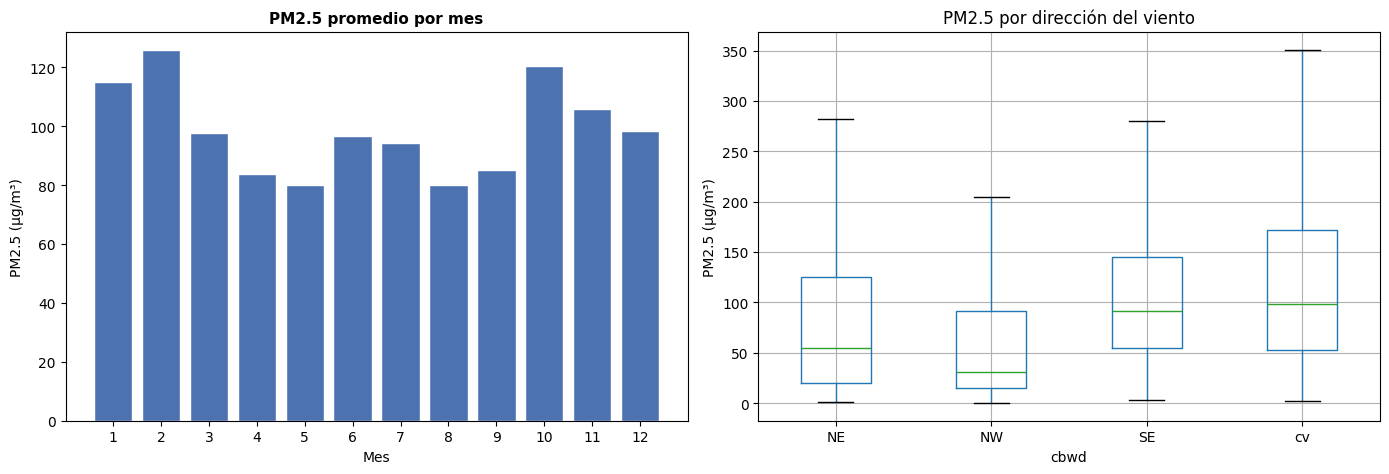

In [7]:
# PM2.5 por mes y por dirección del viento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_notna = df.dropna(subset=['pm2.5'])

pm_mes = df_notna.groupby('month')['pm2.5'].mean()
axes[0].bar(pm_mes.index, pm_mes.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('PM2.5 promedio por mes', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xticks(range(1, 13))

df_notna.boxplot(column='pm2.5', by='cbwd', ax=axes[1], showfliers=False)
axes[1].set_title('PM2.5 por dirección del viento')
axes[1].set_xlabel('cbwd')
axes[1].set_ylabel('PM2.5 (µg/m³)')
plt.suptitle('')
plt.tight_layout()
plt.show()

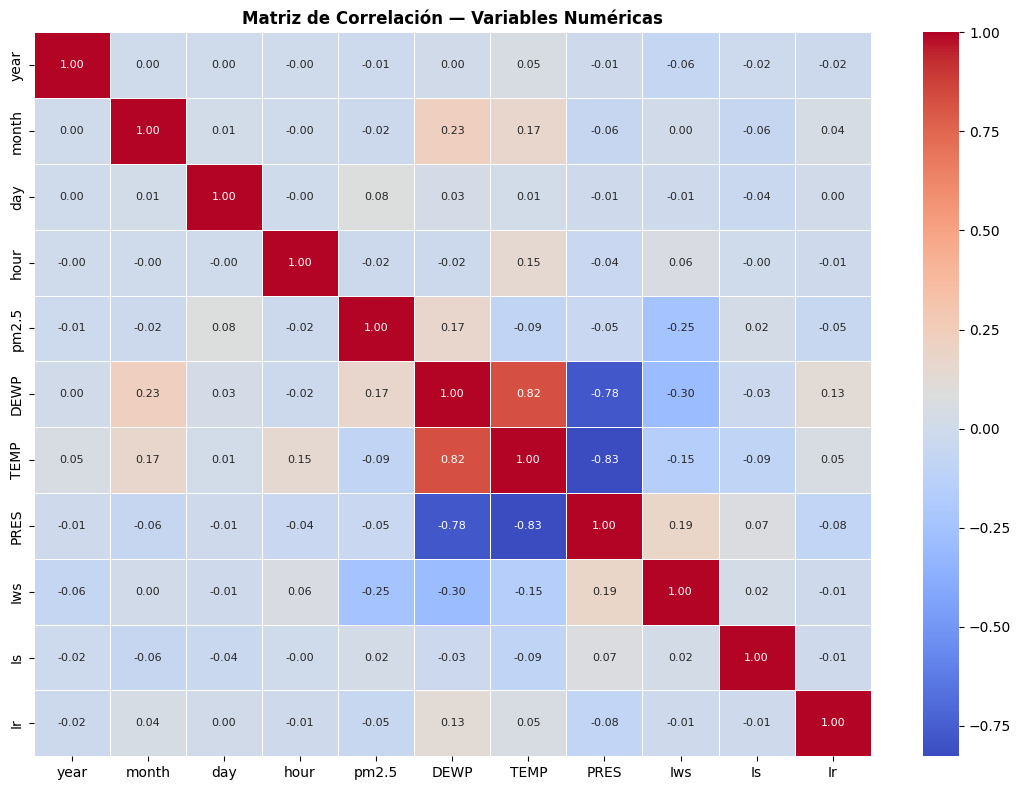

Correlación con pm2.5 (ordenada):
DEWP     0.1714
day      0.0828
Is       0.0193
year    -0.0147
hour    -0.0231
month   -0.0241
PRES    -0.0473
Ir      -0.0514
TEMP    -0.0905
Iws     -0.2478
Name: pm2.5, dtype: float64


In [32]:
# Matriz de correlación
cols_corr = ['year','month','day','hour','pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']
corr = df[cols_corr].corr()
#mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr,annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación con pm2.5 (ordenada):')
corr_y = corr['pm2.5'].drop('pm2.5').sort_values(ascending=False)

print(corr_y.round(4))

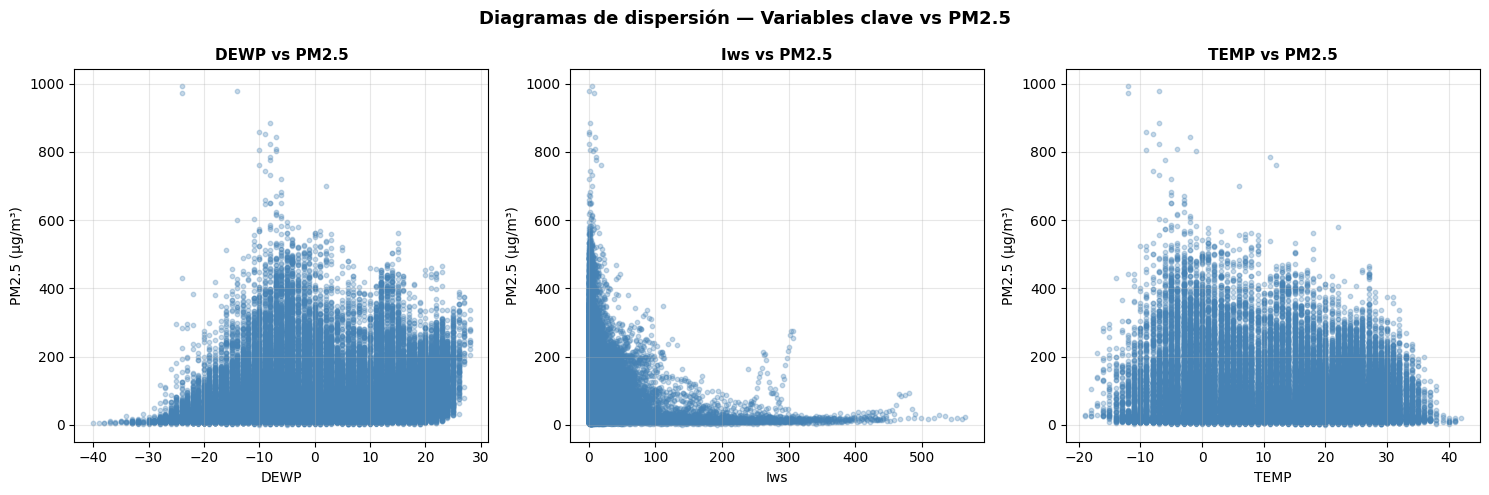

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pares = [('DEWP', 'pm2.5'), ('Iws', 'pm2.5'), ('TEMP', 'pm2.5')]

for i, (x_col, y_col) in enumerate(pares):
    axes[i].scatter(df[x_col], df[y_col], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(x_col, fontsize=10)
    axes[i].set_ylabel('PM2.5 (µg/m³)', fontsize=10)
    axes[i].set_title(f'{x_col} vs PM2.5', fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Diagramas de dispersión — Variables clave vs PM2.5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Preparacion de los Datos

In [9]:
# Definición de X y y
df_modelo = df.drop(columns=['No'])
y_raw = df_modelo['pm2.5']
X_raw = df_modelo.drop(columns=['pm2.5'])

print(f'Variables independientes X: {X_raw.shape[1]}')
for col in X_raw.columns:
    print(f'  - {col} ({X_raw[col].dtype})')
print(f'\nVariable dependiente y: pm2.5')
print(f'  Rango: {y_raw.min()} – {y_raw.max()} µg/m³  |  Nulos: {y_raw.isnull().sum()} ({y_raw.isnull().mean()*100:.2f}%)')

Variables independientes X: 11
  - year (int64)
  - month (int64)
  - day (int64)
  - hour (int64)
  - DEWP (int64)
  - TEMP (float64)
  - PRES (float64)
  - cbwd (str)
  - Iws (float64)
  - Is (int64)
  - Ir (int64)

Variable dependiente y: pm2.5
  Rango: 0.0 – 994.0 µg/m³  |  Nulos: 2067 (4.72%)


Generación de los valores nulos artificiales

In [11]:
# Generar nulos artificiales en TEMP, PRES, Iws (semilla=42, 5%)
cols_num = ['year','month','day','hour','DEWP','TEMP','PRES','Iws','Is','Ir']
cols_cat = ['cbwd']

np.random.seed(SEED)
X_data = X_clean.copy()
for col in ['TEMP', 'PRES', 'Iws']:
    idx = np.random.choice(X_data.index, size=int(len(X_data) * 0.05), replace=False)
    X_data.loc[idx, col] = np.nan

nulos = X_data.isnull().sum()
display(pd.DataFrame({'Nulos': nulos, '%': (nulos / len(X_data) * 100).round(2)})[nulos > 0])

,Nulos,%
TEMP,2087,5.0
PRES,2087,5.0
Iws,2087,5.0


Codificación de variables categoricas - OneHotEncoder

In [12]:
# cbwd tiene 4 categorías nominales (sin orden): NE, NW, SE, cv → 4 dummies
print(f'Categorías únicas de cbwd: {sorted(X_data["cbwd"].unique())}')

filas = [{'Variable': 'cbwd', 'Valor original': cat, 'Columna dummy generada': f'cbwd_{cat}'}
         for cat in sorted(X_data['cbwd'].unique())]

tabla_enc = pd.DataFrame(filas)
tabla_enc.style \
    .set_caption("Codificación OneHotEncoder — cbwd") \
    .set_properties(**{'text-align': 'left'}) \
    .hide(axis='index')

Categorías únicas de cbwd: ['NE', 'NW', 'SE', 'cv']


Variable,Valor original,Columna dummy generada
cbwd,NE,cbwd_NE
cbwd,NW,cbwd_NW
cbwd,SE,cbwd_SE
cbwd,cv,cbwd_cv


Escalado — StandardScaler

Se aplica a todas las variables numéricas porque los rangos son muy distintos (PRES: 991–1046 vs Iws: 0.45–585).
El escalado es indispensable para MLP y PCA. Se aplica dentro del pipeline para evitar data leakage.

4. Seleccion de Caracteristicas (Escenario 1)

In [13]:
# Preprocesamiento exploratorio (solo para calcular correlación, RFE e importancia)
imputer_exp = SimpleImputer(strategy='median')
X_num_imp = pd.DataFrame(imputer_exp.fit_transform(X_data[cols_num]), columns=cols_num)

ohe_exp = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_enc = pd.DataFrame(
    ohe_exp.fit_transform(X_data[cols_cat]),
    columns=ohe_exp.get_feature_names_out(cols_cat)
)
scaler_exp = StandardScaler()
X_num_sc = pd.DataFrame(scaler_exp.fit_transform(X_num_imp), columns=cols_num)
X_exp = pd.concat([X_num_sc, X_cat_enc], axis=1)

print(f'Dataset para análisis exploratorio: {X_exp.shape}')

Dataset para análisis exploratorio: (41757, 14)


4.1 Correlacion con pm2.5

In [14]:
X_corr = X_num_imp.copy()
X_corr['pm2.5'] = y_clean.values
corr_y = X_corr.corr()['pm2.5'].drop('pm2.5').sort_values(ascending=False)
print(corr_y.round(4))

DEWP     0.1714
day      0.0828
Is       0.0193
year    -0.0147
hour    -0.0231
month   -0.0241
PRES    -0.0465
Ir      -0.0514
TEMP    -0.0865
Iws     -0.2406
Name: pm2.5, dtype: float64


4.2 RFE -Recursive Feature Elimination

In [15]:
rfe = RFE(estimator=Ridge(), n_features_to_select=6)
rfe.fit(X_exp, y_clean)

df_rfe = pd.DataFrame({
    'Variable':     X_exp.columns,
    'Ranking':      rfe.ranking_,
    'Seleccionada': rfe.support_
}).sort_values('Ranking')
display(df_rfe.reset_index(drop=True))

,Variable,Ranking,Seleccionada
0,TEMP,1,True
1,DEWP,1,True
2,cbwd_NE,1,True
3,cbwd_NW,1,True
4,cbwd_SE,1,True
5,cbwd_cv,1,True
6,Iws,2,False
7,PRES,3,False
8,Ir,4,False
9,day,5,False


4.3 Importacia por Random Forest

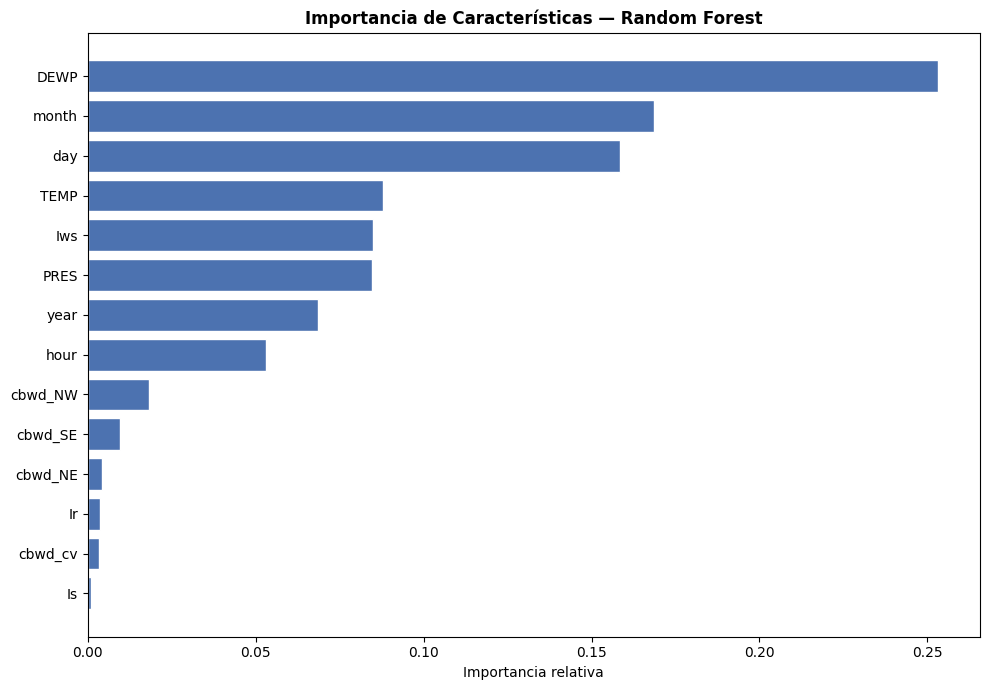

In [16]:
rf_sel = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_sel.fit(X_exp, y_clean)

df_imp = pd.DataFrame({
    'Variable':    X_exp.columns,
    'Importancia': rf_sel.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_imp['Variable'], df_imp['Importancia'], color='#4C72B0', edgecolor='white')
ax.set_title('Importancia de Características — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

4.4 Selección Final

In [17]:
features_e1 = ['DEWP', 'month', 'day', 'TEMP', 'Iws', 'PRES']

tabla_sel = pd.DataFrame({
    'Característica': features_e1,
    'Correlación':    ['+0.17', '-0.02', '+0.08', '-0.09', '-0.24', '-0.05'],
    'RFE (Ridge)':    ['Si', '—', '—', 'Si', '—', '—'],
    'RF Importancia': ['1° (0.253)', '2° (0.168)', '3° (0.159)', '4° (0.088)', '5° (0.085)', '6° (0.085)'],
    'Decisión':       ['INCLUIR'] * 6
})
tabla_sel.style \
    .hide(axis='index') \
    .set_caption(f'Características seleccionadas finales ({len(features_e1)})')

Característica,Correlación,RFE (Ridge),RF Importancia,Decisión
DEWP,+0.17,Si,1° (0.253),INCLUIR
month,-0.02,—,2° (0.168),INCLUIR
day,+0.08,—,3° (0.159),INCLUIR
TEMP,-0.09,Si,4° (0.088),INCLUIR
Iws,-0.24,—,5° (0.085),INCLUIR
PRES,-0.05,—,6° (0.085),INCLUIR


5. PCA — Análisis de Componentes Principales (Escenario 2)

In [18]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_exp)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(var_acum >= 0.95)) + 1

df_pca = pd.DataFrame({
    'Componente':     range(1, X_exp.shape[1] + 1),
    'Varianza expl.': pca_full.explained_variance_ratio_.round(4),
    'Acumulada':      var_acum.round(4)
})
display(df_pca)

,Componente,Varianza expl.,Acumulada
0,1,0.2569,0.2569
1,2,0.1033,0.3602
2,3,0.1005,0.4607
3,4,0.0976,0.5583
4,5,0.0926,0.6509
5,6,0.0893,0.7401
6,7,0.0873,0.8274
7,8,0.0807,0.9081
8,9,0.0261,0.9342
9,10,0.0210,0.9552


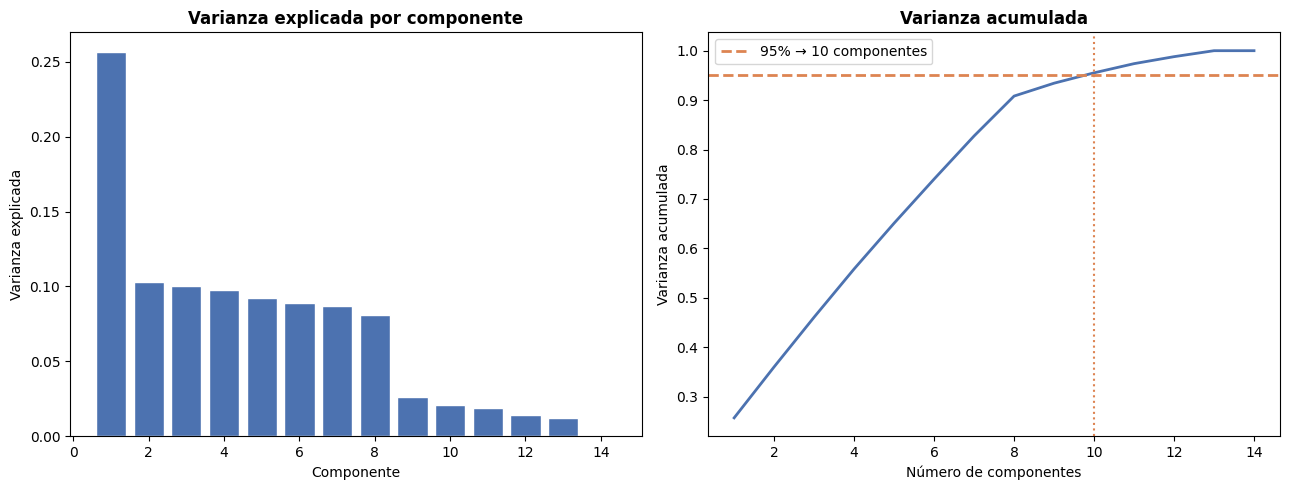

Componentes seleccionados: 10 (explican 95.5% de la varianza)
PCA se aplica DENTRO del pipeline en cada fold para evitar leakage.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='#4C72B0', edgecolor='white')
axes[0].set_title('Varianza explicada por componente', fontweight='bold')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')

axes[1].plot(range(1, len(var_acum) + 1), var_acum, color='#4C72B0', lw=2)
axes[1].axhline(0.95, color='#DD8452', linestyle='--', lw=2, label=f'95% → {n_95} componentes')
axes[1].axvline(n_95, color='#DD8452', linestyle=':')
axes[1].set_title('Varianza acumulada', fontweight='bold')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

N_PCA = n_95
print(f'Componentes seleccionados: {N_PCA} (explican {var_acum[N_PCA-1]*100:.1f}% de la varianza)')
print('PCA se aplica DENTRO del pipeline en cada fold para evitar leakage.')

6. Modelado y Evaluación — 6 Experimentos

Algoritmos:
- Random Forest: (n_estimators=300): ensemble de árboles, robusto a outliers, captura relaciones no lineales.
- Gradient Boosting: (n_estimators=200, lr=0.1, depth=5): árboles aditivos secuenciales que minimizan el error residual.
- MLPRegressor: (256-128-64, early_stopping=True): red neuronal densa, captura patrones complejos.

Escenarios:
- Escenario 1: SimpleImputer - StandardScaler - Modelo (6 características seleccionadas)
- Escenario 2: ColumnTransformer(impute+scale+OHE) -  PCA - Modelo (todas las variables)

In [20]:
kf = KFold(n_splits=7, shuffle=True, random_state=SEED)
scoring = {
    'r2':  make_scorer(r2_score),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False)
}

def make_pipe_e1(modelo):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   modelo)
    ])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
preprocessor_e2 = ColumnTransformer([
    ('num', num_pipe, cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cols_cat)
])

def make_pipe_e2(modelo):
    return Pipeline([
        ('preprocessor', preprocessor_e2),
        ('pca',   PCA(n_components=N_PCA, random_state=SEED)),
        ('model', modelo)
    ])

X_e1 = X_data[features_e1]
X_e2 = X_data[cols_num + cols_cat]

print(f'KFold: n_splits=7, shuffle=True, seed={SEED}')
print(f'Escenario 1 — {len(features_e1)} características: {features_e1}')
print(f'Escenario 2 — PCA ({N_PCA} componentes)')

KFold: n_splits=7, shuffle=True, seed=42
Escenario 1 — 6 características: ['DEWP', 'month', 'day', 'TEMP', 'Iws', 'PRES']
Escenario 2 — PCA (10 componentes)


In [21]:
modelos_config = [
    ('Random Forest',
     RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ('Gradient Boosting',
     GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=SEED)),
    ('Red Neuronal (MLP)',
     MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=1000,
                  early_stopping=True, random_state=SEED))
]

escenarios_config = [
    ('Características seleccionadas', X_e1, make_pipe_e1),
    ('PCA',                           X_e2, make_pipe_e2)
]

resultados = []

for nombre_esc, X_esc, make_pipe in escenarios_config:
    for nombre_mod, modelo in modelos_config:
        inicio = time.time()
        pipe = make_pipe(modelo)
        cv   = cross_validate(pipe, X_esc, y_clean, cv=kf, scoring=scoring)
        t    = time.time() - inicio
        r2s  = cv['test_r2']
        maes = -cv['test_mae']
        resultados.append({
            'Escenario':  nombre_esc,
            'Modelo':     nombre_mod,
            'R² medio':   round(r2s.mean(), 4),
            'Desv. R²':   round(r2s.std(),  4),
            'Var. R²':    round(r2s.var(),  6),
            'MAE medio':  round(maes.mean(), 4),
            'Desv. MAE':  round(maes.std(),  4),
            'Var. MAE':   round(maes.var(),  6),
            'R² folds':   r2s,
            'Tiempo (s)': round(t, 2)
        })
        print(f'{nombre_esc[:25]:25s} | {nombre_mod:20s} | R²={r2s.mean():.4f} ± {r2s.std():.4f} | {t:.0f}s')

Características seleccion | Random Forest        | R²=0.7810 ± 0.0460 | 47s
Características seleccion | Gradient Boosting    | R²=0.6515 ± 0.0233 | 39s
Características seleccion | Red Neuronal (MLP)   | R²=0.6506 ± 0.0280 | 378s
PCA                       | Random Forest        | R²=0.6594 ± 0.0198 | 189s
PCA                       | Gradient Boosting    | R²=0.4780 ± 0.0160 | 215s
PCA                       | Red Neuronal (MLP)   | R²=0.7009 ± 0.0282 | 405s


Resultados comparativos

In [22]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'R² folds'} for r in resultados])

display(df_res.style
    .hide(axis='index')
    .highlight_max(subset=['R² medio'], color='#d4edda')
    .highlight_min(subset=['MAE medio'], color='#d4edda')
    .format({'R² medio': '{:.4f}', 'Desv. R²': '{:.4f}', 'Var. R²': '{:.6f}',
             'MAE medio': '{:.4f}', 'Desv. MAE': '{:.4f}', 'Var. MAE': '{:.6f}'})
)

Escenario,Modelo,R² medio,Desv. R²,Var. R²,MAE medio,Desv. MAE,Var. MAE,Tiempo (s)
Características seleccionadas,Random Forest,0.7810,0.0460,0.002119,26.6646,2.1628,4.677606,47.300000
Características seleccionadas,Gradient Boosting,0.6515,0.0233,0.000544,37.2214,0.9136,0.834682,38.770000
Características seleccionadas,Red Neuronal (MLP),0.6506,0.0280,0.000783,36.6556,1.5130,2.289144,377.650000
PCA,Random Forest,0.6594,0.0198,0.000393,36.1133,1.3080,1.710992,189.060000
PCA,Gradient Boosting,0.4780,0.0160,0.000257,47.7796,0.7821,0.611743,215.000000
PCA,Red Neuronal (MLP),0.7009,0.0282,0.000796,33.4658,1.4231,2.025327,404.590000


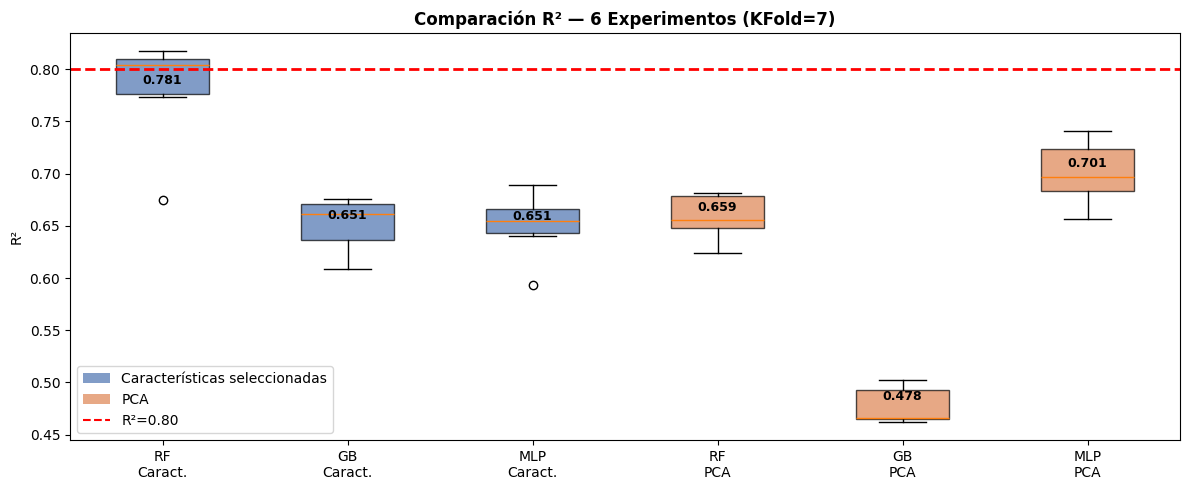

Mejor modelo: Características seleccionadas — Random Forest
R² = 0.781 ± 0.046  |  MAE = 26.6646 µg/m³


In [23]:
etiquetas = ['RF\nCaract.', 'GB\nCaract.', 'MLP\nCaract.',
             'RF\nPCA',    'GB\nPCA',    'MLP\nPCA']
r2_folds = [r['R² folds'] for r in resultados]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(r2_folds, labels=etiquetas, patch_artist=True)

colores = ['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#DD8452']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.80, color='red', linestyle='--', lw=2, label='R²=0.80 (objetivo)')
for i, vals in enumerate(r2_folds):
    ax.text(i + 1, np.mean(vals) + 0.005, f'{np.mean(vals):.3f}',
            ha='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C72B0', alpha=0.7, label='Características seleccionadas'),
    Patch(facecolor='#DD8452', alpha=0.7, label='PCA'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='R²=0.80')
])
ax.set_title('Comparación R² — 6 Experimentos (KFold=7)', fontsize=12, fontweight='bold')
ax.set_ylabel('R²')
plt.tight_layout()
plt.show()

mejor = max(resultados, key=lambda x: x['R² medio'])
print(f'Mejor modelo: {mejor["Escenario"]} — {mejor["Modelo"]}')
print(f'R² = {mejor["R² medio"]} ± {mejor["Desv. R²"]}  |  MAE = {mejor["MAE medio"]} µg/m³')

7. Análisis del mejor Modelo

Tabla de 7 particiones

In [24]:
pipe_mejor = make_pipe_e1(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))
cv_mejor = cross_validate(pipe_mejor, X_e1, y_clean, cv=kf, scoring=scoring)

r2_m  = cv_mejor['test_r2']
mae_m = -cv_mejor['test_mae']

df_parts = pd.DataFrame({
    'Partición': list(range(1, 8)) + ['Media', 'Desv. Est.', 'Varianza'],
    'R²':  list(r2_m.round(4))   + [round(r2_m.mean(), 4),  round(r2_m.std(), 4),  round(r2_m.var(), 6)],
    'MAE': list(mae_m.round(4))  + [round(mae_m.mean(), 4), round(mae_m.std(), 4), round(mae_m.var(), 6)]
})
display(df_parts.style.hide(axis='index'))

print(f'Varianza R² = {r2_m.var():.6f} — {"Baja (< 0.01)" if r2_m.var() < 0.01 else "Moderada"}')

Partición,R²,MAE
1,0.674600,31.849300
2,0.779700,26.131300
3,0.807600,25.283900
4,0.772900,26.679400
5,0.803800,25.713500
6,0.811100,25.353800
7,0.817100,25.640800
Media,0.781000,26.664600
Desv. Est.,0.046000,2.162800
Varianza,0.002119,4.677606


Varianza R² = 0.002119 — Baja (< 0.01)


Intentos de mejora documentados 

In [25]:
configs_mejora = [
    ('RF base (n=300)',  RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ('RF n=200',         RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)),
    ('RF n=400',         RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1)),
]

mejoras = []
for nombre, mod in configs_mejora:
    s = cross_val_score(make_pipe_e1(mod), X_e1, y_clean, cv=kf, scoring='r2')
    mejoras.append({'Configuración': nombre, 'R² medio': round(s.mean(), 4), 'Desv.': round(s.std(), 4)})

# Referencia con 10 variables numéricas
pipe_10 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))
])
s10 = cross_val_score(pipe_10, X_data[cols_num], y_clean, cv=kf, scoring='r2')
mejoras.append({'Configuración': 'RF + 10 vars numéricas (referencia)', 'R² medio': round(s10.mean(), 4), 'Desv.': round(s10.std(), 4)})

display(pd.DataFrame(mejoras).style
    .highlight_max(subset=['R² medio'], color='#d4edda')
    .hide(axis='index')
)
print('Con 6 features el techo es ~0.78-0.79.')
print('Con 10 variables se supera 0.83, pero excede el límite de 4-6 características del proyecto.')

Configuración,R² medio,Desv.
RF base (n=300),0.781000,0.046000
RF n=200,0.779800,0.046600
RF n=400,0.780900,0.045900
RF + 10 vars numéricas (referencia),0.838600,0.042900


Con 6 features el techo es ~0.78-0.79.
Con 10 variables se supera 0.83, pero excede el límite de 4-6 características del proyecto.


Evaluación Final (train_test_split 80/20)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_e1, y_clean, test_size=0.20, random_state=SEED
)

pipe_eval = make_pipe_e1(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))
pipe_eval.fit(X_train, y_train)
y_pred = pipe_eval.predict(X_test)

r2_final  = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)

print(f'Entrenamiento : {X_train.shape[0]:,} registros')
print(f'Prueba        : {X_test.shape[0]:,} registros')
print(f'R²  en prueba : {r2_final:.4f}')
print(f'MAE en prueba : {mae_final:.4f} µg/m³')

Entrenamiento : 33,405 registros
Prueba        : 8,352 registros
R²  en prueba : 0.6982
MAE en prueba : 30.7148 µg/m³


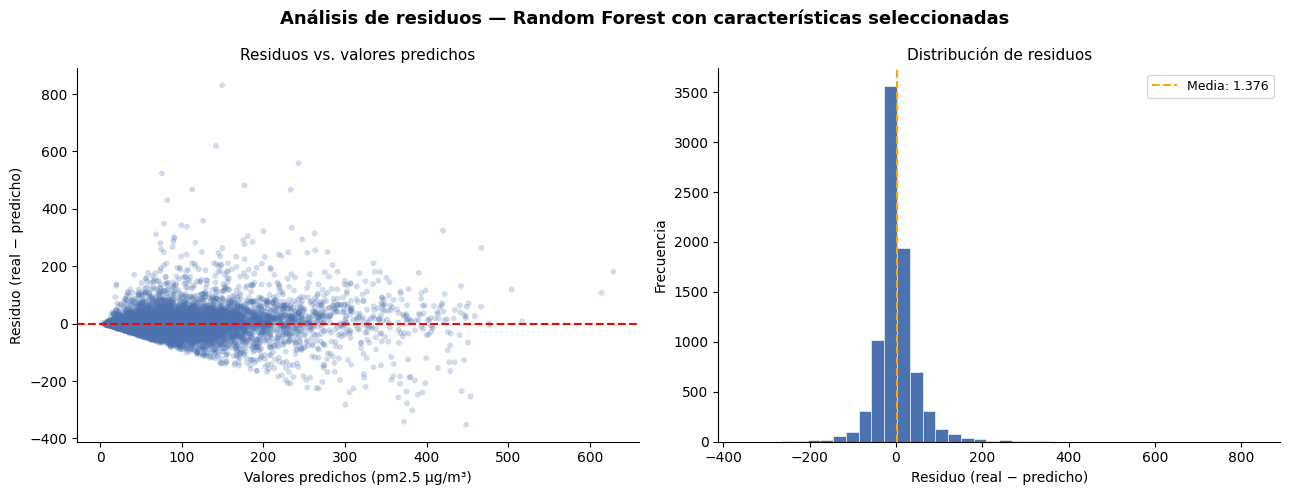

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análisis de residuos — Random Forest con características seleccionadas',
             fontsize=13, fontweight='bold')

residuos = y_test.values - y_pred

# ── Residuos vs. valores predichos ───────────────────────────────
axes[0].scatter(y_pred, residuos, alpha=0.25, color='#4C72B0', s=18, edgecolors='none')
axes[0].axhline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('Residuos vs. valores predichos', fontsize=11)
axes[0].set_xlabel('Valores predichos (pm2.5 µg/m³)', fontsize=10)
axes[0].set_ylabel('Residuo (real − predicho)', fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# ── Distribución de residuos ──────────────────────────────────────
axes[1].hist(residuos, bins=40, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[1].axvline(residuos.mean(), color='orange', lw=1.5, ls='--',
                label=f'Media: {residuos.mean():.3f}')
axes[1].set_title('Distribución de residuos', fontsize=11)
axes[1].set_xlabel('Residuo (real − predicho)', fontsize=10)
axes[1].set_ylabel('Frecuencia', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('residuos_final.png', dpi=150, bbox_inches='tight')
plt.show()

 8. Entrenamiento Final y Guardado del Pipeline

In [28]:
X_final = X_clean[features_e1]

pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))
])
pipeline_final.fit(X_final, y_clean)

os.makedirs('modelo', exist_ok=True)
joblib.dump(pipeline_final, 'modelo/pipeline_pm25.pkl')
print(f'Pipeline entrenado con {len(X_final):,} registros')
print(f'Guardado en: modelo/pipeline_pm25.pkl')

Pipeline entrenado con 41,757 registros
Guardado en: modelo/pipeline_pm25.pkl


In [29]:
# Verificación de carga y predicción
pipe_cargado = joblib.load('modelo/pipeline_pm25.pkl')
ej = pd.DataFrame([{'DEWP': 2.0, 'month': 1, 'day': 15, 'TEMP': -5.0, 'Iws': 5.37, 'PRES': 1016.0}])
pred_ej = pipe_cargado.predict(ej)[0]
print(f'Predicción de prueba: PM2.5 = {pred_ej:.2f} µg/m³')

print('\nRangos de variables (para formulario Flask):')
for col in features_e1:
    print(f'  {col}: min={X_clean[col].min():.1f}, max={X_clean[col].max():.1f}')

Predicción de prueba: PM2.5 = 335.72 µg/m³

Rangos de variables (para formulario Flask):
  DEWP: min=-40.0, max=28.0
  month: min=1.0, max=12.0
  day: min=1.0, max=31.0
  TEMP: min=-19.0, max=42.0
  Iws: min=0.5, max=565.5
  PRES: min=991.0, max=1046.0


9. Despliegue en Render
URL pública:

La aplicación fue desarrollada con Flask y expone un formulario donde el usuario ingresa los 6 valores meteorológicos. El pipeline aplica internamente la imputación y el escalado antes de retornar la predicción de PM2.5 en µg/m³ con clasificación de calidad del aire (EPA).

Archivos:
- app.py — servidor Flask (GET/POST)
- modelo/pipeline_pm25.pkl — pipeline entrenado
- templates/index.html — formulario HTML
- requirements.txt — dependencias (flask, scikit-learn, joblib, gunicorn, pandas, numpy)
- Comando de inicio en Render: gunicorn app:app

10. Conclusiones

Mejor modelo: Random Forest con características seleccionadas (DEWP, month, day, TEMP, Iws, PRES) — R²=0.7810 ± 0.0460 | MAE=26.66 µg/m³ | Varianza R²=0.002119

R² < 0.80: Con el límite de 6 características el techo es 0.78-0.79. Con 10 variables se alcanza 0.84, pero excede el límite del proyecto. La limitación es intrínseca: pm2.5 depende fuertemente de la autocorrelación temporal (valor de la hora anterior) que no está disponible como predictor estático.

Hallazgos clave:
- El Escenario 1 (características seleccionadas) supera al Escenario 2 (PCA) para RF y GB. MLP se beneficia del PCA.
- DEWP es el predictor más importante (importancia=0.253): mayor humedad - menor dispersión - más PM2.5.
- Iws tiene la mayor correlación negativa (-0.24): el viento dispersa los contaminantes.
- Los residuos son heterocedásticos: errores mayores en picos extremos de PM2.5 (>400 µg/m³).